In [1]:
from modules.utils import merge_devtest_csvs
from modules.viz import ConfigLookup, metric_x_point, test_summary
from pathlib import Path
import numpy as np
import pandas as pd

In [2]:
# compiling dfs
# folder = Path('./output/2025-12-13_13h35m29s_reconstr_grid4c')
# folder = Path('./output/2025-12-13_17h00m28s_reconstr_grid4c2')
# dev = pd.read_csv(folder/'dev.csv')
# test = pd.read_csv(folder/'test.csv')

folder = Path('./output/reconstr_grid4c2')
subfolders = ['t1', 't2', 't3']
dev = merge_devtest_csvs(folder, subfolders, 'dev.csv', save=True)
test = merge_devtest_csvs(folder, subfolders, 'test.csv', save=True)

# get confs, update
confs_class = ConfigLookup(
    keys=['ema_norm','loss_weights'],
    configs=dev['config'].unique().tolist(),
    path=folder,
    save=True,
)

confs = confs_class.data

# merge with confs
dev = pd.merge(confs, dev,on='config')
test = pd.merge(confs, test,on='config')

In [3]:
test['loss_weights'] = test['loss_weights'].astype(str)
test

,ema_norm,loss_weights,config,trial,metric,value
0,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,loss,0.464993
1,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,mse,0.718069
2,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,rmse,0.847390
3,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,mae,0.575347
4,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,r2,0.808461
...,...,...,...,...,...,...
1045,True,"[1, 1e-06]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,29,rmse,0.736977
1046,True,"[1, 1e-06]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,29,mae,0.486531
1047,True,"[1, 1e-06]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,29,r2,0.855931
1048,True,"[1, 1e-06]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,29,kld,282.060303


In [4]:
test_summary(test, save_csv=True, filename=folder/'summary.csv')

,config,metric,mean,sd,ci
0,losskwargsEmanormTruelossclassesMSELossKLDLoss...,kld,46.050934,38.881373,14.518543
1,losskwargsEmanormTruelossclassesMSELossKLDLoss...,loss,0.520349,0.039127,0.014610
2,losskwargsEmanormTruelossclassesMSELossKLDLoss...,mae,0.540485,0.044046,0.016447
3,losskwargsEmanormTruelossclassesMSELossKLDLoss...,mse,0.647754,0.091793,0.034276
4,losskwargsEmanormTruelossclassesMSELossKLDLoss...,r2,0.830959,0.023388,0.008733
5,losskwargsEmanormTruelossclassesMSELossKLDLoss...,rmse,0.802862,0.057231,0.021370
6,losskwargsEmanormTruelossclassesMSELossKLDLoss...,time,383.770398,0.669166,0.249871
7,losskwargsEmanormTruelossclassesMSELossKLDLoss...,kld,141.026697,115.881321,43.270796
8,losskwargsEmanormTruelossclassesMSELossKLDLoss...,loss,0.522322,0.044199,0.016504
9,losskwargsEmanormTruelossclassesMSELossKLDLoss...,mae,0.545986,0.041684,0.015856


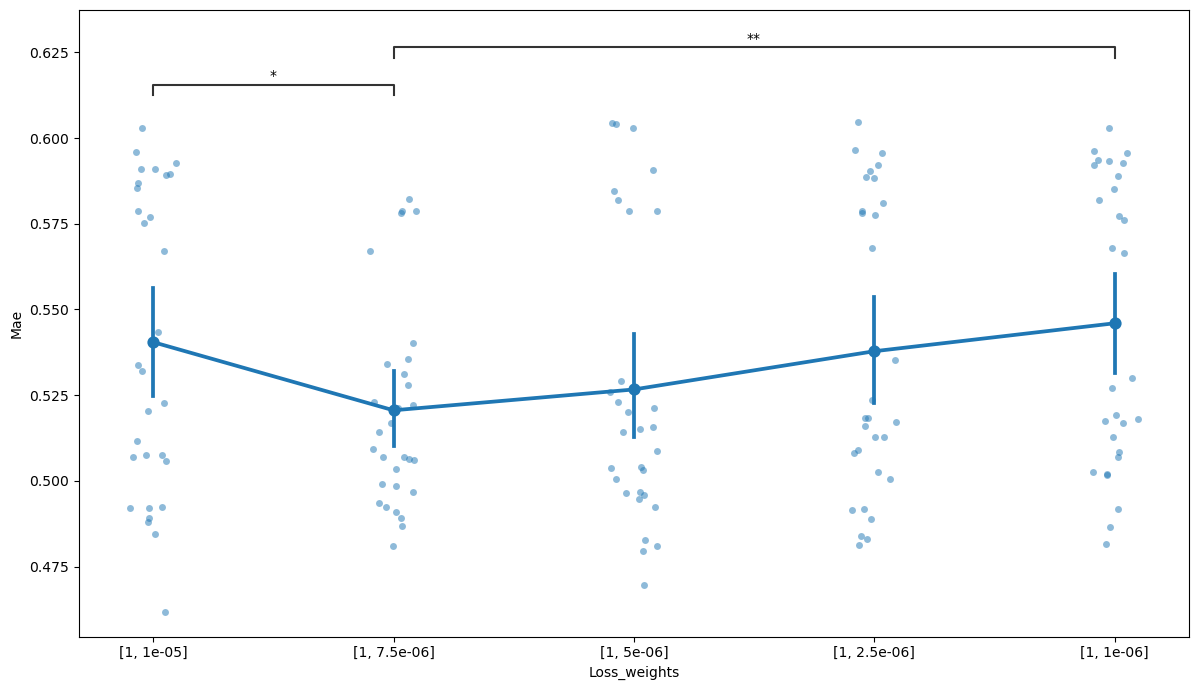

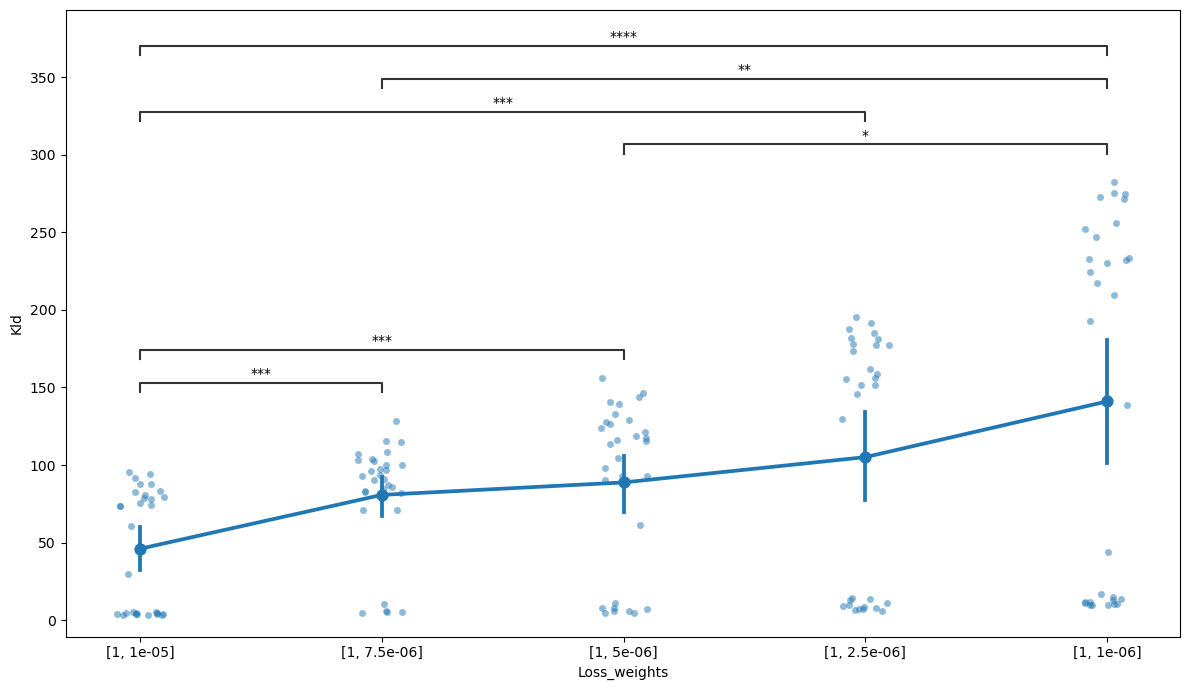

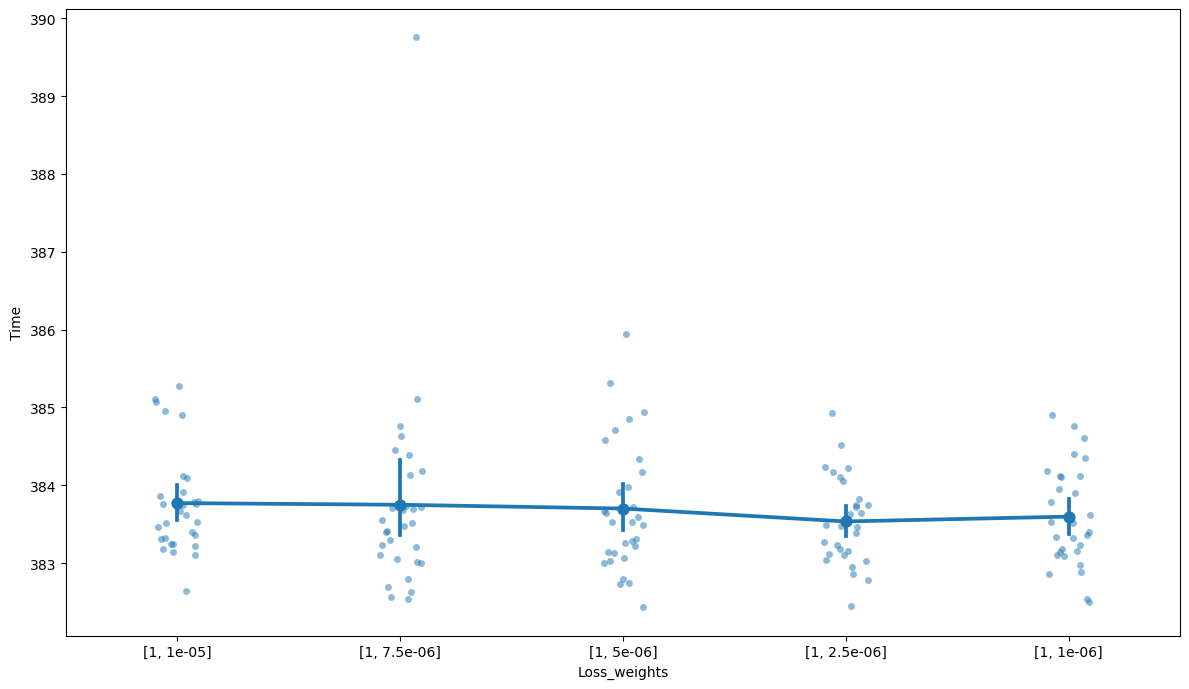

In [5]:
metric_x_point(
    df=test, 
    cols=['loss_weights'],
    metrics=['mae', 'kld', 'time'],
    figsize=(12,7),
    strip=True,
    sig=True
)

In [6]:
from modules.viz import devplot

In [7]:
dev['loss_weights'] = dev['loss_weights'].astype(str)
dev

,ema_norm,loss_weights,config,trial,epoch,stage,metric,value
0,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,0,train,loss,0.507897
1,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,0,train,mse,0.823018
2,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,0,train,rmse,0.907203
3,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,0,train,mae,0.618323
4,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,0,train,r2,0.786090
...,...,...,...,...,...,...,...,...
539995,True,"[1, 1e-06]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,29,299,val,mse,0.541230
539996,True,"[1, 1e-06]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,29,299,val,rmse,0.735683
539997,True,"[1, 1e-06]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,29,299,val,mae,0.485558
539998,True,"[1, 1e-06]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,29,299,val,r2,0.858390


In [8]:
summary = pd.read_csv(folder/'summary.csv')
summary = pd.merge(confs,summary,on='config')
summary['loss_weights'] = summary['loss_weights'].astype(str)
summary


,ema_norm,loss_weights,config,metric,mean,sd,ci
0,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,kld,46.050934,38.881373,14.518543
1,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,loss,0.520349,0.039127,0.014610
2,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,mae,0.540485,0.044046,0.016447
3,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,mse,0.647754,0.091793,0.034276
4,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,r2,0.830959,0.023388,0.008733
5,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,rmse,0.802862,0.057231,0.021370
6,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,time,383.770398,0.669166,0.249871
7,True,"[1, 7.5e-06]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,kld,80.765523,36.110835,13.484007
8,True,"[1, 7.5e-06]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,loss,0.541545,0.043317,0.016175
9,True,"[1, 7.5e-06]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,mae,0.520607,0.029865,0.011152


In [9]:
figs = devplot(
    dev=dev,
    summary=summary,
    metrics=['mae', 'kld']
)

In [10]:
for key in figs.keys():
    print(key)

losskwargsEmanormTruelossclassesMSELossKLDLosslossweights11e-5
losskwargsEmanormTruelossclassesMSELossKLDLosslossweights17.5e-6
losskwargsEmanormTruelossclassesMSELossKLDLosslossweights15e-6
losskwargsEmanormTruelossclassesMSELossKLDLosslossweights12.5e-6
losskwargsEmanormTruelossclassesMSELossKLDLosslossweights11e-6


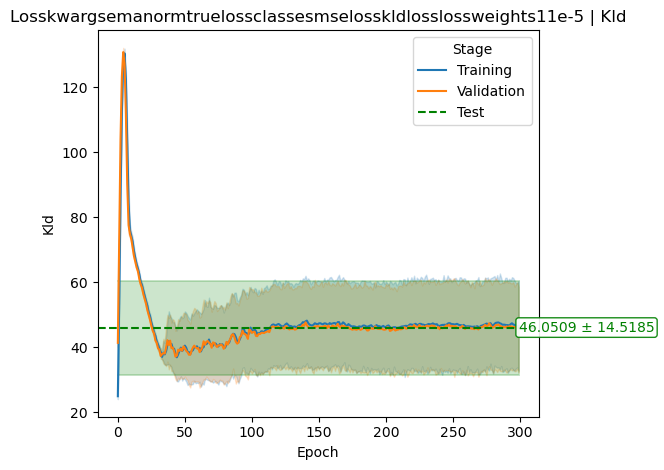

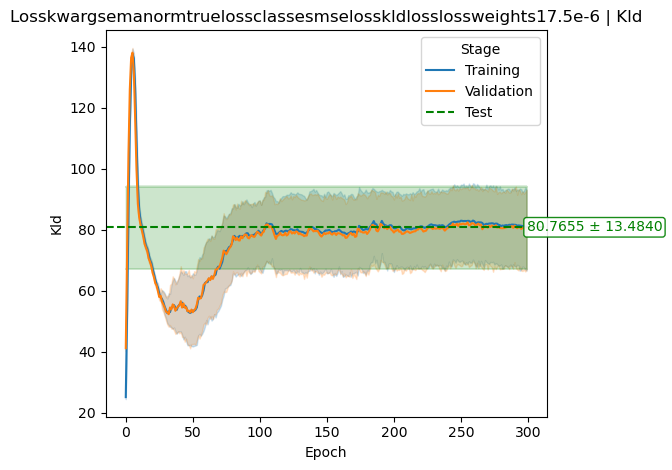

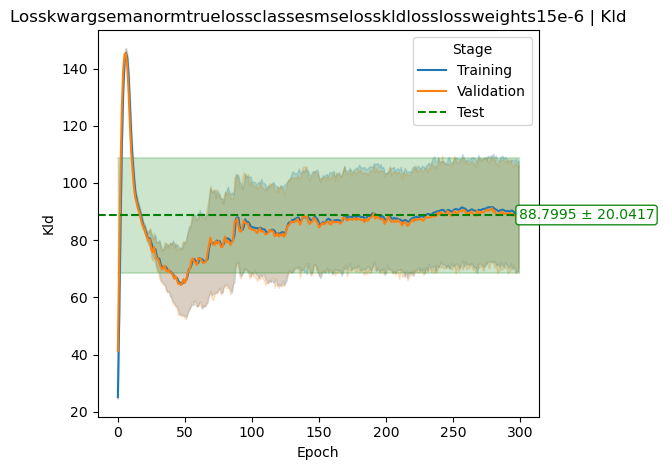

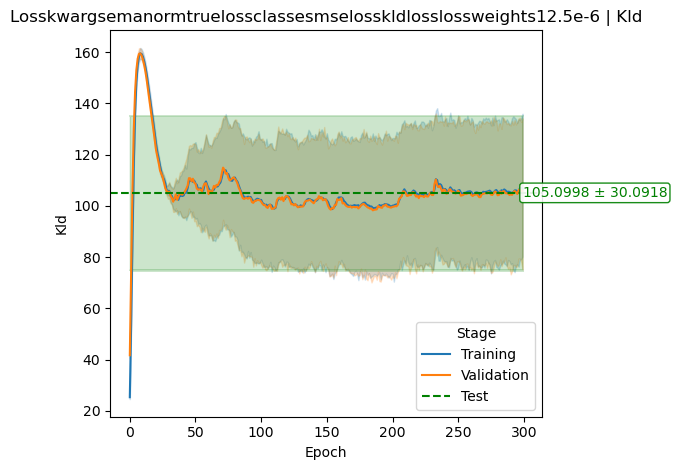

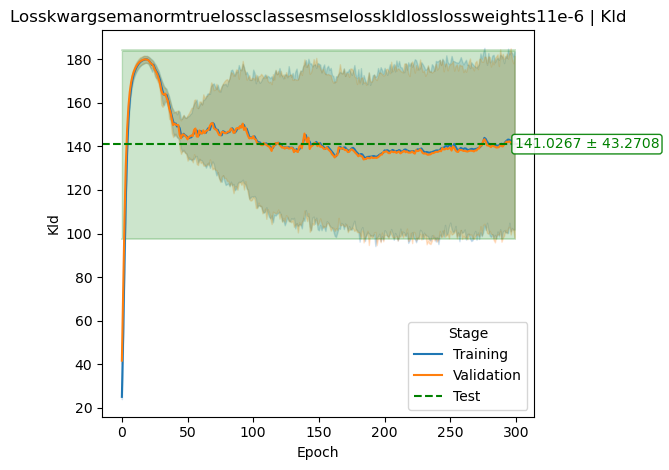

In [11]:
for key in figs.keys():
    display(figs[key]['kld'])

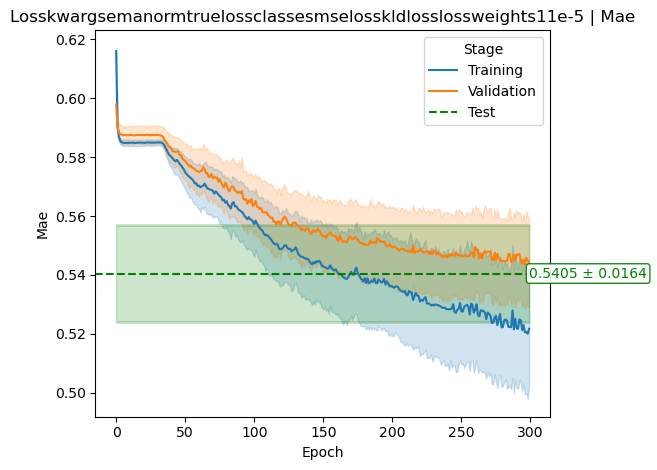

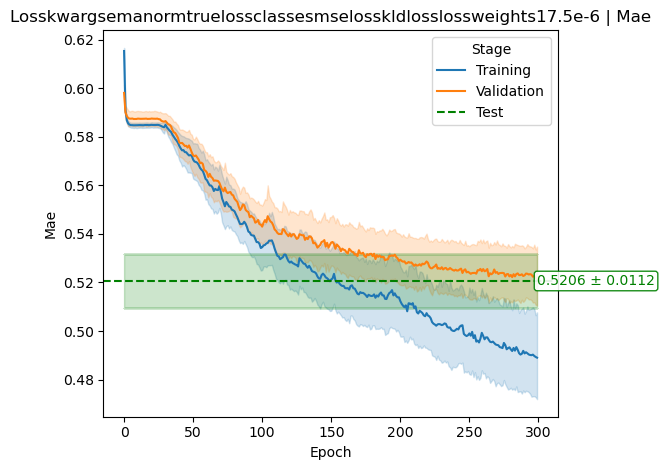

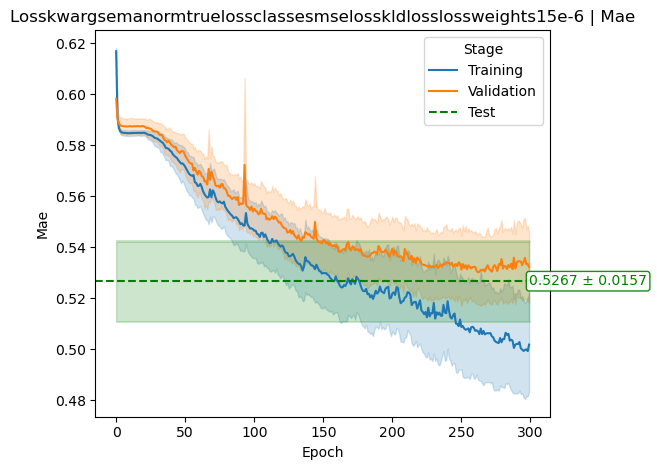

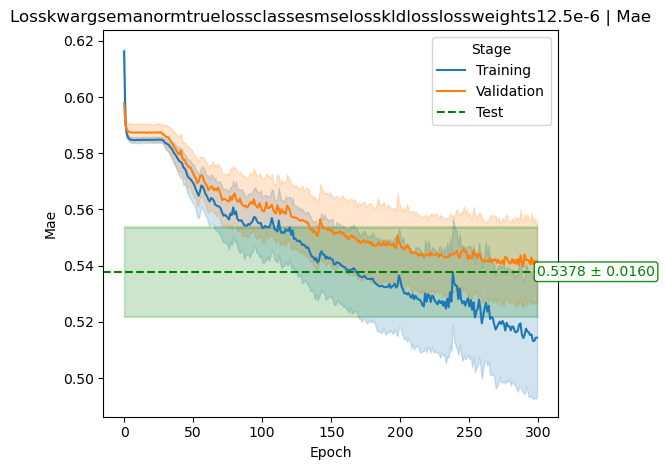

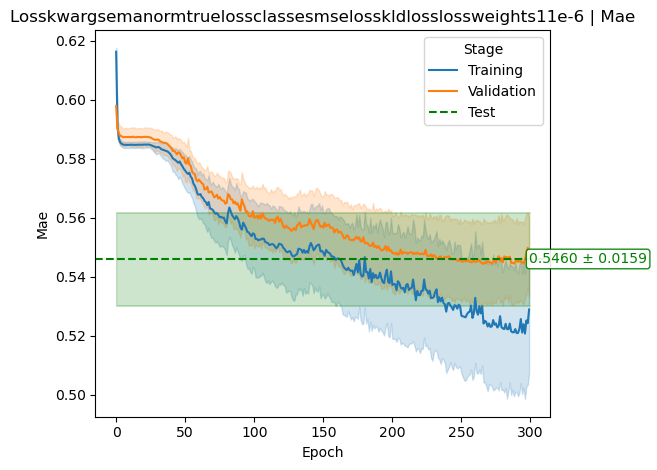

In [12]:
for key in figs.keys():
    display(figs[key]['mae'])